# 0 IMPORTACIÓN DE BIBLIOTECAS Y LIBRERÍAS

In [1]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import skew, kurtosis, norm
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import shap
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import *
from imblearn.metrics import specificity_score
import statsmodels.api as sm
import joblib

c:\Users\ingen\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1 INGESTIÓN O CARGA DE DATOS

In [2]:
df_original = pd.read_csv(r"C:\Users\ingen\OneDrive\Escritorio\CURSO DE DATA SCIENCE\ULTIMO PROYECTO\cathycaz-intro-ml\data\raw\diabetes.csv")

print(f"TAMAÑO DEL DATASET: {df_original.shape[0]} filas x {df_original.shape[1]} columnas")

TAMAÑO DEL DATASET: 768 filas x 9 columnas


# 2 INSPECCIÓN INICIAL

## 2.1 VISUALIZACIÓN DE TODAS LAS COLUMNAS 

In [3]:
pd.set_option('display.max_columns', None)
# Esto sirve para que me muestre todas las columnas cuando un DataSet es muy ancho o con muchas columnas 
# Con el (None) le digo que me muestre todas las columnas sin limitación
df_original.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


## 2.2 INFORMACIÓN DEL DATASET 

In [4]:
# Información general del dataset
print("INFORMACIÓN GENERAL:")
print("="*80)
df_original.info()

print("\n" + "="*80)

# Lista de columnas
print("COLUMNAS DEL DATASET:\n")
print(df_original.columns.tolist())


INFORMACIÓN GENERAL:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

COLUMNAS DEL DATASET:

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


## 2.3 CLASIFICACIÓN DE COLUMNAS DEL DATASET PARA DETECTAR NÚMERICAS, CATEGÓRICAS, BOOLEANAS Y DATETIME

In [5]:
numerical_cols = df_original.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("\n" + "="*80)
print("COLUMNAS NUMÉRICAS:\n")
print(numerical_cols)
print(f"Cantidad de Columnas Numéricas: {len(numerical_cols)}")

categorical_cols = df_original.select_dtypes(include=['object', 'category']).columns.tolist()
print("\n" + "="*80)
print("COLUMNAS CATEGÓRICAS:\n")
print(categorical_cols)
print(f"Cantidad de Columnas Categóricas: {len(categorical_cols)}")

boolean_cols = df_original.select_dtypes(include=['bool']).columns.tolist()
print("\n" + "="*80)    
print("COLUMNAS BOOLEANAS:\n")
print(boolean_cols)
print(f"Cantidad de Columnas Booleanas: {len(boolean_cols)}")

datetime_cols = df_original.select_dtypes(include=['datetime64']).columns.tolist()
print("\n" + "="*80)    
print("COLUMNAS DE FECHA Y HORA:\n")
print(datetime_cols)
print(f"Cantidad de Columnas de Fecha y Hora: {len(datetime_cols)}")


COLUMNAS NUMÉRICAS:

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Cantidad de Columnas Numéricas: 9

COLUMNAS CATEGÓRICAS:

[]
Cantidad de Columnas Categóricas: 0

COLUMNAS BOOLEANAS:

[]
Cantidad de Columnas Booleanas: 0

COLUMNAS DE FECHA Y HORA:

[]
Cantidad de Columnas de Fecha y Hora: 0


## 2.4 DESCRIPCIÓN GENERAL DEL DATASET

In [6]:
df_original.describe(include='all').T # Include all sirve para que me muestre todas las estadísticas de todas las variables, incluyendo las categóricas

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 2.5 ANÁLISIS DE DISTRIBUCCIÓN PARA COLUMNAS NÚMERICAS

In [7]:
numerical_cols = df_original.select_dtypes(include=['int64', 'float64']).columns

# Crear DataFrame con estadísticas de distribución
dist_stats = pd.DataFrame({
    'Variable': numerical_cols,
    'Media': [df_original[col].mean() for col in numerical_cols],
    'Mediana': [df_original[col].median() for col in numerical_cols],
    'Desv_Std': [df_original[col].std() for col in numerical_cols],
    'Skewness': [skew(df_original[col].dropna()) for col in numerical_cols],
    'Kurtosis': [kurtosis(df_original[col].dropna()) for col in numerical_cols]
})

# Determinar tipo de distribución
def clasificar_distribucion(skew_val, kurt_val):
    # Clasificar por skewness 
    # ¿Hacia dónde se inclina?
    if abs(skew_val) < 0.5:
        tipo_skew = "Simétrica"
    elif skew_val > 0.5:
        tipo_skew = "Asimétrica +"
    else:
        tipo_skew = "Asimétrica -"
    
    # Clasificar por kurtosis
    # ¿Qué tan puntiaguda es? 
    # La kurtosis mayor a 1 es la que me indica cuantos outliers tengo 
    # mientras mas se aleja de 1 mayor atención debo prestar a esa variable
    if kurt_val > 1:
        tipo_kurt = "Leptocúrtica"
    elif kurt_val < -1:
        tipo_kurt = "Platicúrtica"
    else:
        tipo_kurt = "Mesocúrtica"
    
    return f"{tipo_skew} | {tipo_kurt}"

dist_stats['Tipo_Distribución'] = dist_stats.apply(
    lambda row: clasificar_distribucion(row['Skewness'], row['Kurtosis']), axis=1
)

# Redondear valores para mejor visualización
dist_stats = dist_stats.round(3)

print("=" * 100)
print("ANÁLISIS DE DISTRIBUCIÓN POR VARIABLE")
print("=" * 100)
print("\nGuía de Interpretación:")
print("  • Skewness: |valor| < 0.5 (Simétrica), > 0.5 (Asimétrica +), < -0.5 (Asimétrica -)")
print("  • Kurtosis: > 1 (Leptocúrtica/Puntiaguda), < -1 (Platicúrtica/Achatada), entre -1 y 1 (Mesocúrtica/Normal)")
print("\n")

dist_stats

ANÁLISIS DE DISTRIBUCIÓN POR VARIABLE

Guía de Interpretación:
  • Skewness: |valor| < 0.5 (Simétrica), > 0.5 (Asimétrica +), < -0.5 (Asimétrica -)
  • Kurtosis: > 1 (Leptocúrtica/Puntiaguda), < -1 (Platicúrtica/Achatada), entre -1 y 1 (Mesocúrtica/Normal)




,Variable,Media,Mediana,Desv_Std,Skewness,Kurtosis,Tipo_Distribución
0,Pregnancies,3.845,3.000,3.370,0.900,0.150,Asimétrica + | Mesocúrtica
1,Glucose,120.895,117.000,31.973,0.173,0.629,Simétrica | Mesocúrtica
2,BloodPressure,69.105,72.000,19.356,-1.840,5.139,Asimétrica - | Leptocúrtica
3,SkinThickness,20.536,23.000,15.952,0.109,-0.524,Simétrica | Mesocúrtica
4,Insulin,79.799,30.500,115.244,2.268,7.160,Asimétrica + | Leptocúrtica
5,BMI,31.993,32.000,7.884,-0.428,3.261,Simétrica | Leptocúrtica
6,DiabetesPedigreeFunction,0.472,0.372,0.331,1.916,5.551,Asimétrica + | Leptocúrtica
7,Age,33.241,29.000,11.760,1.127,0.631,Asimétrica + | Mesocúrtica
8,Outcome,0.349,0.000,0.477,0.634,-1.598,Asimétrica + | Platicúrtica


## 2.6 HISTOGRAMA DE DISTRIBUCCIÓN PARA COLUMNAS NÚMERICAS

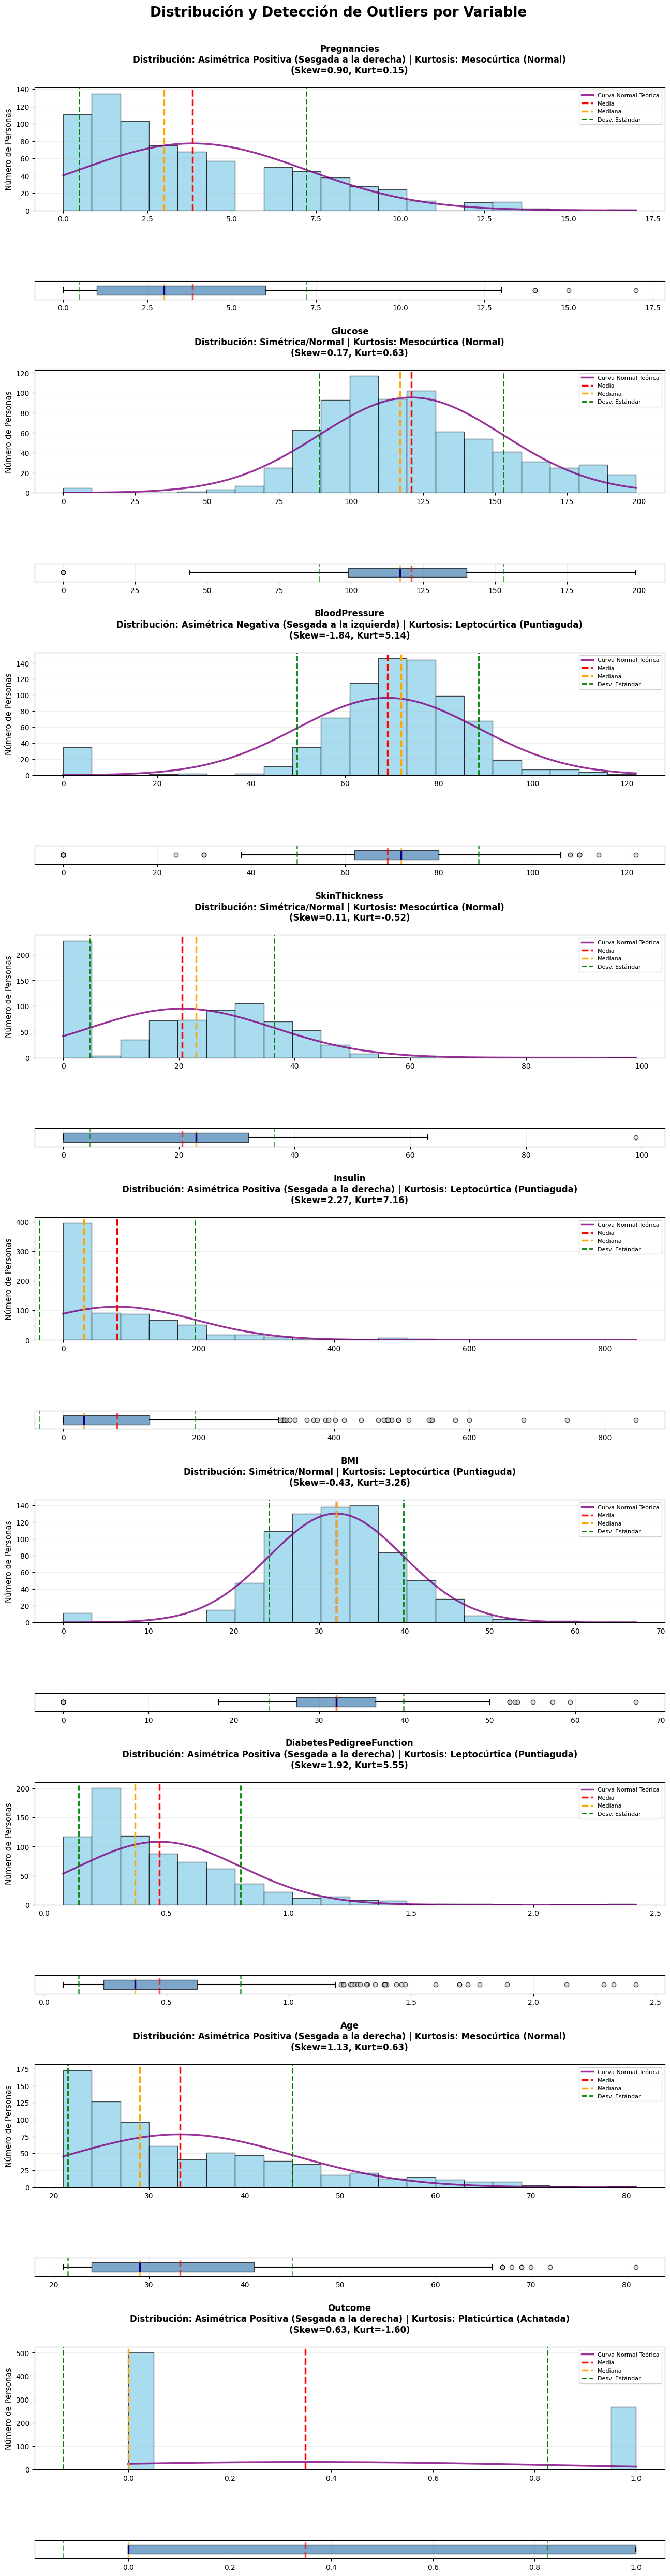

In [8]:
# Histogramas con estadísticas y boxplots
fig = plt.figure(figsize=(14, 50))
gs = fig.add_gridspec(18, 1, hspace=1, height_ratios=[10, 1.5] * 9)

row = 0
for idx, col in enumerate(numerical_cols):
    data = df_original[col].dropna()
    
    # Calcular estadísticas
    mean_val = data.mean()
    median_val = data.median()
    std_val = data.std()
    skewness = skew(data) 
    kurt = kurtosis(data) 
    
    # Determinar tipo de distribución por skewness
    if abs(skewness) < 0.5:
        dist_type = "Simétrica/Normal"
    elif skewness > 0.5:
        dist_type = "Asimétrica Positiva (Sesgada a la derecha)"
    else:
        dist_type = "Asimétrica Negativa (Sesgada a la izquierda)"
    
    # Determinar tipo de kurtosis
    if kurt > 1:
        kurt_type = "Leptocúrtica (Puntiaguda)"
    elif kurt < -1:
        kurt_type = "Platicúrtica (Achatada)"
    else:
        kurt_type = "Mesocúrtica (Normal)"
    
    # Histograma (fila superior) - CONTEO DE PERSONAS
    ax_hist = fig.add_subplot(gs[row, 0])
    n, bins, patches = ax_hist.hist(data, bins=20, edgecolor='black', alpha=0.7, 
                                      color='skyblue', density=False)
    
    # Superponer curva normal de referencia - ESCALADA AL CONTEO
    x = np.linspace(data.min(), data.max(), 100)
    # Escalar la curva normal para que se ajuste al histograma de conteos
    bin_width = bins[1] - bins[0]  # Ancho de cada barra
    scale_factor = len(data) * bin_width  # Factor de escala
    ax_hist.plot(x, norm.pdf(x, mean_val, std_val) * scale_factor, 
                 color='purple', linewidth=2.5, linestyle='-', 
                 label='Curva Normal Teórica', alpha=0.8)
    
    # Líneas verticales de estadísticas
    ax_hist.axvline(mean_val, color='red', linestyle='--', linewidth=2.5, 
                    label=f'Media')
    ax_hist.axvline(median_val, color='orange', linestyle='--', linewidth=2.5, 
                    label=f'Mediana')
    ax_hist.axvline(mean_val + std_val, color='green', linestyle='--', linewidth=2, 
                    label=f'Desv. Estándar')
    ax_hist.axvline(mean_val - std_val, color='green', linestyle='--', linewidth=2)
    
    # Título con tipo de distribución, skewness y kurtosis
    ax_hist.set_title(f'{col}\nDistribución: {dist_type} | Kurtosis: {kurt_type}\n(Skew={skewness:.2f}, Kurt={kurt:.2f})', 
                      fontsize=12, fontweight='bold', pad=20)
    ax_hist.set_ylabel('Número de Personas', fontsize=11)
    ax_hist.legend(fontsize=8, loc='upper right', framealpha=0.9)
    ax_hist.grid(True, alpha=0.2, axis='y')
    
    # Boxplot horizontal (fila inferior)
    ax_box = fig.add_subplot(gs[row + 1, 0])
    bp = ax_box.boxplot(data, vert=False, patch_artist=True, widths=0.5,
                         boxprops=dict(facecolor='steelblue', alpha=0.7, edgecolor='black'),
                         medianprops=dict(color='darkblue', linewidth=2.5),
                         whiskerprops=dict(color='black', linewidth=1.5),
                         capprops=dict(color='black', linewidth=1.5),
                         flierprops=dict(marker='o', markerfacecolor='lightgray', 
                                       markeredgecolor='black', markersize=6, alpha=0.7))
    
    # Proyectar líneas de estadísticas en el boxplot
    ax_box.axvline(mean_val, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
    ax_box.axvline(median_val, color='orange', linestyle='--', linewidth=2.5, alpha=0.7)
    ax_box.axvline(mean_val + std_val, color='green', linestyle='--', linewidth=2, alpha=0.7)
    ax_box.axvline(mean_val - std_val, color='green', linestyle='--', linewidth=2, alpha=0.7)
    
    ax_box.set_xlim(ax_hist.get_xlim())
    ax_box.grid(True, alpha=0.2, axis='x')
    ax_box.tick_params(axis='y', which='both', left=False, labelleft=False)
    ax_box.set_xlabel('')
    
    row += 2

plt.suptitle('Distribución y Detección de Outliers por Variable', 
             fontsize=19, fontweight='bold', y=1.002)
plt.subplots_adjust(top=0.97, bottom=0.015, left=0.08, right=0.95)
plt.show()

# 3 CRIBADO DE VARIABLES 

## 3.1 DFINICIÓN DE OBJETIVO DE ESTUDIO 

### El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes.

#### En este conjunto de datos encontrarás las siguientes variables:

- Pregnancies. Número de embarazos del paciente (numérico)

- Glucose. Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)

- BloodPressure. Presión arterial diastólica (medida en mm Hg) (numérico)

- SkinThickness. Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico)

- Insulin. Insulina sérica de 2 horas (medida en mu U/ml) (numérico)

- BMI. Índice de masa corporal (numérico)

- DiabetesPedigreeFunction. Función de pedigrí de diabetes (numérico)

- Age. Edad del paciente (numérico)

- Outcome. Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1, positivo (numérico)

## 3.2 CREACIÓN DE DATASET PARA TRABAJAR

In [9]:
df = df_original.copy()

## 3.3 VERIFICACIÓN DE VALORES ÚNICOS POR CADA COLUMNA Y BÚSQUEDA DE VALORES FALTANTES ENMASCARADOS

In [10]:
# Verificar columnas con valores únicos igual a 1
columnas_un_valor = df.nunique()[df.nunique() == 1]

if len(columnas_un_valor) > 0:
    print("="*50)
    print("COLUMNAS CON VALORES ÚNICOS = 1")
    print("="*50)
    print("\n Nombres de las Columnas:")
    print(columnas_un_valor.index.tolist())
    print(f"\n Total de Columnas con un Solo Valor: {len(columnas_un_valor)}")
else:
    print("="*50)
    print("No hay Columnas con Valores Únicos igual a 1")
    print("="*50)

# Análisis de valores únicos por columna
for columna in df.columns: # → Recorre todas las columnas 
    print(f"\n{'='*25}")
    print(f"COLUMNA: {columna}")
    print(f"{'='*25}")
    print(df[columna].value_counts()) # Muestra cada valor único y cuántas veces aparece, ordenado de mayor a menor frecuencia
    print(f"\nTotal de Valores Únicos: {df[columna].nunique()}") # → Cuenta cuántos valores diferentes hay en total  

No hay Columnas con Valores Únicos igual a 1

COLUMNA: Pregnancies
Pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
17      1
15      1
Name: count, dtype: int64

Total de Valores Únicos: 17

COLUMNA: Glucose
Glucose
99     17
100    17
111    14
125    14
129    14
       ..
56      1
169     1
149     1
65      1
190     1
Name: count, Length: 136, dtype: int64

Total de Valores Únicos: 136

COLUMNA: BloodPressure
BloodPressure
70     57
74     52
78     45
68     45
72     44
64     43
80     40
76     39
60     37
0      35
62     34
66     30
82     30
88     25
84     23
90     22
86     21
58     21
50     13
56     12
54     11
52     11
92      8
75      8
65      7
85      6
94      6
48      5
44      4
96      4
110     3
106     3
100     3
98      3
30      2
46      2
55      2
104     2
108     2
40      1
122     1
95      1
102     1
61      1
24      1
38 

## 3.4 VERIFICACIÓN DE DATOS FALTANTES EN COLUMNAS

In [11]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## 3.5 VERIFICACIÓN DE DATOS FALTANTES EN FILAS > 40%

In [12]:
df_filas_faltantes = (df.T.isnull().sum()* 100 / len(df)).round(2)
if df_filas_faltantes[df_filas_faltantes > 0.40].any():
    print(df_filas_faltantes[df_filas_faltantes > 0.40])
else:
    print("No hay Filas con Valores Faltantes > 40 % en el DataSet")

No hay Filas con Valores Faltantes > 40 % en el DataSet


## 3.6 GRÁFICA DE VALORES FALTANTES 

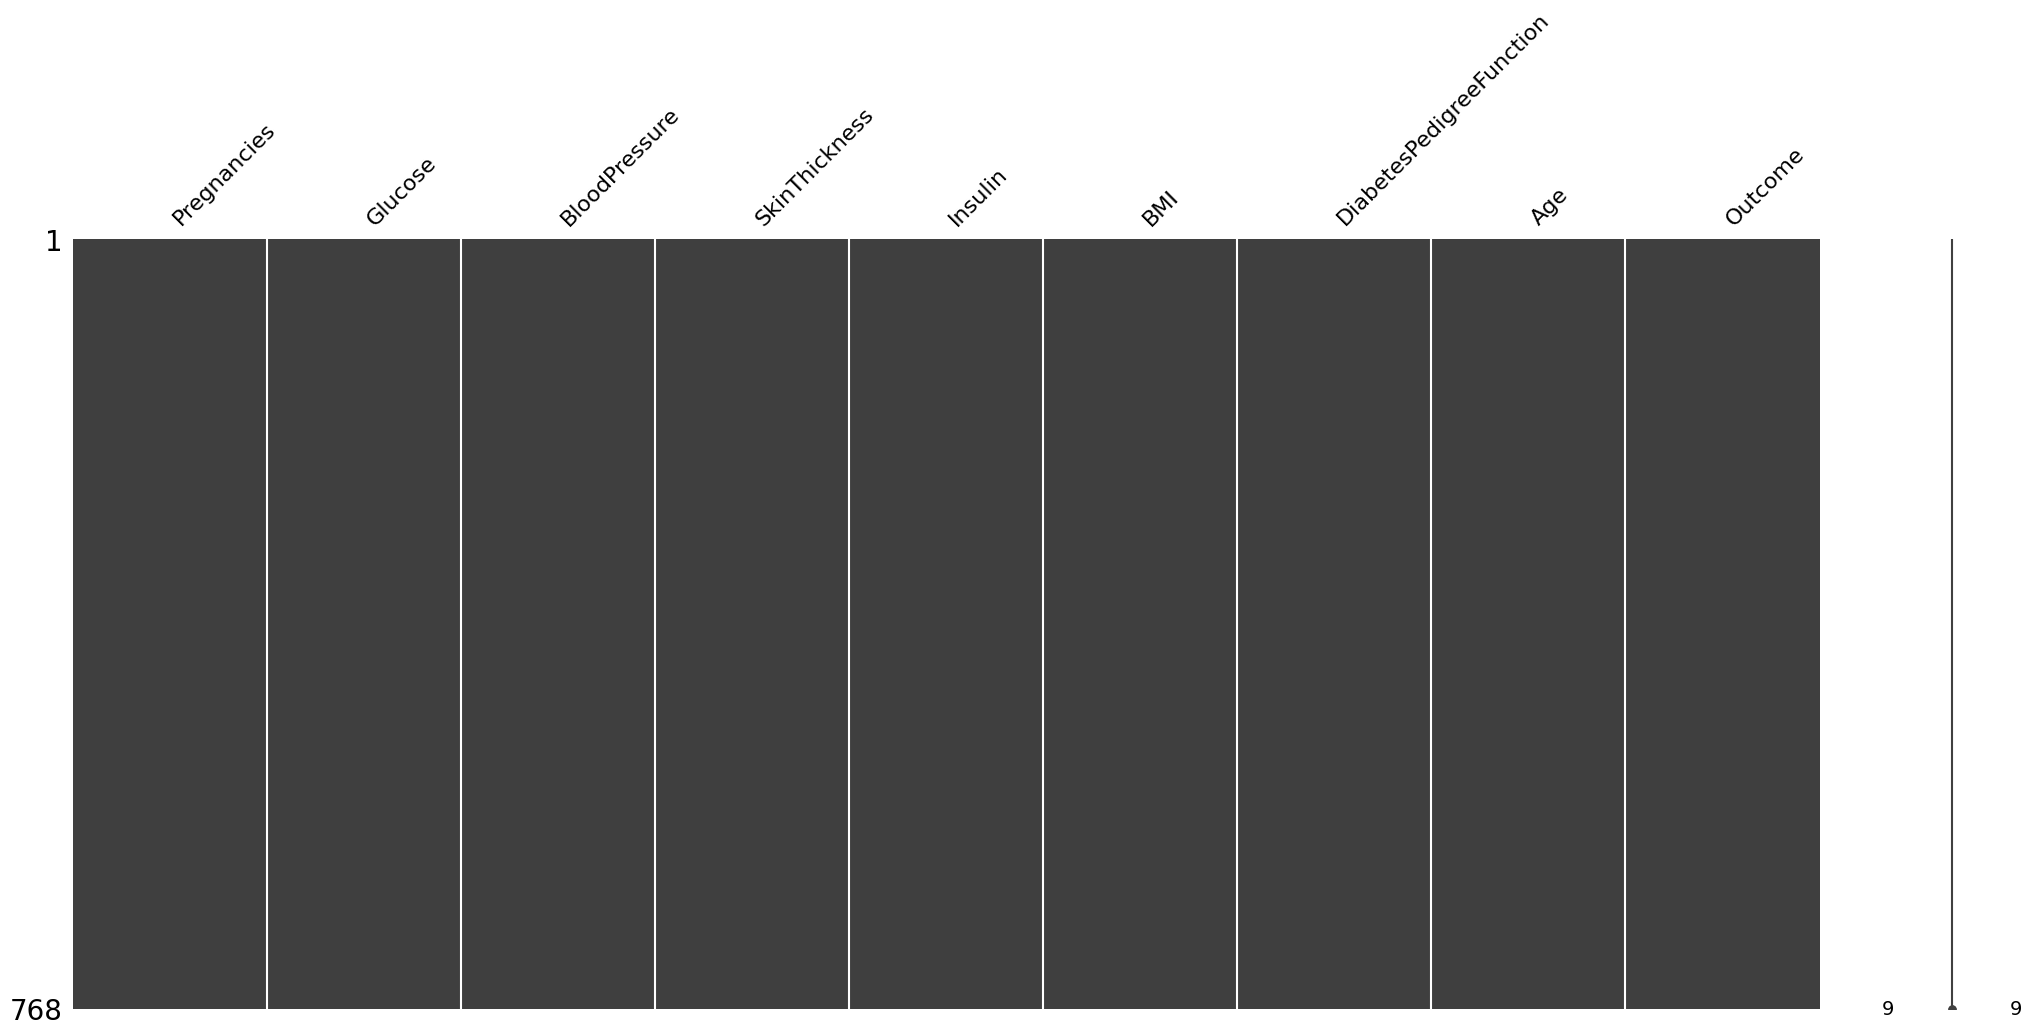

In [13]:
msno.matrix(df)
plt.show()

## 3.7 COMPROBACIÓN DE DATOS DUPLICADOS EN FILAS

In [14]:
filas_duplicadas = df[df.duplicated(keep=False)] # keep=False muestra TODAS las ocurrencias (incluyendo la original)

if len(filas_duplicadas) > 0:
    print(f"Se Encontraron {len(filas_duplicadas)} Filas Duplicadas:")
    print(f"Esto Representa {len(filas_duplicadas)/len(df)*100:.2f}% del DataSet\n")
    print(filas_duplicadas)
else:
    print("No hay Filas Duplicadas en el DataSet")

No hay Filas Duplicadas en el DataSet


## 3.9 COMPROBACIÓN DE DATOS DUPLICADOS EN COLUMNAS CON LA TRANSPUESTA

In [15]:
columnas_duplicadas = df.T.duplicated(keep=False).sum()

if columnas_duplicadas > 0:
    print(f"\nSe Encontraron {columnas_duplicadas} Columnas Duplicadas")
    print("\nNombres de las Columnas Duplicadas:")
    print(df.T[df.T.duplicated(keep=False)].index)
else:
    print("\nNo hay Columnas Duplicadas en el DataSet")


No hay Columnas Duplicadas en el DataSet


## 3.10 DETECCIÓN DE OUTLIERS 

In [16]:
# Lista de columnas que quiero analizar
columnas = [col for col in df.columns]

# Para guardar los resultados
resultados = []

# Analizar cada columna una por una
for columna in columnas:
    
    # Obtener los datos de la columna
    datos = df[columna]
    
    # Calcular Q1 (25%), Q3 (75%) y IQR
    Q1 = datos.quantile(0.25)  # 25% de los datos
    Q3 = datos.quantile(0.75)  # 75% de los datos
    IQR = Q3 - Q1              # Diferencia entre Q3 y Q1
    
    # Calcular límites
    limite_bajo = Q1 - 1.5 * IQR
    limite_alto = Q3 + 1.5 * IQR
    
    # Contar outliers
    outliers_bajos = (datos < limite_bajo).sum()
    outliers_altos = (datos > limite_alto).sum()
    total_outliers = outliers_bajos + outliers_altos
    
    # Calcular porcentaje
    porcentaje = (total_outliers / len(datos)) * 100
    
    # Guardar en la lista
    resultados.append({
        'Columna': columna,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Limite_Bajo': limite_bajo,
        'Limite_Alto': limite_alto,
        'Total_Outliers': total_outliers,
        'Porcentaje': round(porcentaje, 2)
    })

# Convertir a DataFrame para verlo bonito
df_outliers = pd.DataFrame(resultados)

# Mostrar resultados
print("="*80)
print("ANÁLISIS DE OUTLIERS")
print("="*80)
print(df_outliers)
print("="*80)

# Explicar qué significa
print("\nINTERPRETACIÓN:")
for i in range(len(df_outliers)):
    col = df_outliers.loc[i, 'Columna']
    limite_bajo = df_outliers.loc[i, 'Limite_Bajo']
    limite_alto = df_outliers.loc[i, 'Limite_Alto']
    total = df_outliers.loc[i, 'Total_Outliers']
    pct = df_outliers.loc[i, 'Porcentaje']
    
    print(f"\n{col}:")
    print(f"  - Valores Normales: Entre {limite_bajo:.1f} y {limite_alto:.1f}")
    print(f"  - Outliers Encontrados: {total} ({pct}%)")
    
    if pct < 5:
        print(f"Pocos Outliers, Está Bien")
    elif pct < 10:
        print(f"Algunos Outliers")
    else:
        print(f"Muchos Outliers")
        
print("="*80)
print("\nSUMA DEL TOTAL DE OUTLIERS EN PORCENTAJE:")
print(df_outliers['Porcentaje'].sum())

ANÁLISIS DE OUTLIERS
                    Columna        Q1         Q3       IQR  Limite_Bajo  \
0               Pregnancies   1.00000    6.00000    5.0000       -6.500   
1                   Glucose  99.00000  140.25000   41.2500       37.125   
2             BloodPressure  62.00000   80.00000   18.0000       35.000   
3             SkinThickness   0.00000   32.00000   32.0000      -48.000   
4                   Insulin   0.00000  127.25000  127.2500     -190.875   
5                       BMI  27.30000   36.60000    9.3000       13.350   
6  DiabetesPedigreeFunction   0.24375    0.62625    0.3825       -0.330   
7                       Age  24.00000   41.00000   17.0000       -1.500   
8                   Outcome   0.00000    1.00000    1.0000       -1.500   

   Limite_Alto  Total_Outliers  Porcentaje  
0       13.500               4        0.52  
1      202.125               5        0.65  
2      107.000              45        5.86  
3       80.000               1        0.13  
4  

CONCLUSIÓN: EN LA INSPECCIÓN GENERAL VEMOS QUE LOS GRÁFICOS NOS MUESTRAN KURTOSIS ALTAS EN VARIABLES COMO (BloodPressure, Insulin, BMI, DiabetesPedigreeFunction) INDICANDONOS ASÍ UNA ALERTA DE QUE HAY UN COMPORTAMIENTO EXTRAÑO EN LOS DATOS Y QUE DEBEMOS ESTUDIAR ESTAS VARIABLES MAS A FONDO A VER QUE SUCEDE.

EN EL ESTUDIO DE OUTLIERS CON PERCENTILES (IQR) CALCULAMOS LA CANTIDAD EN PORCENTAJE QUE SIGNIFICAN ESTOS VALORES EXTRAÑOS DENTRO DEL DATASET.

AMBOS VALORES TIENEN RAZÓN PERO EXPRESAN COSAS DIFERENTES! LA KURTOSIS MIDE FORMA Y PESO DE COLAS, MIENTRAS QUE LOS OUTLIERS DEPENDEN DE UN CRITERIO DE CORTE.

## 3.11 TRANSFORMACIÓN DE VARIABLES CON VALORES ANÓMALOS

In [17]:
# ESTRATEGIA: Variables con Kurtosis Alta pero Outliers IQR Bajos
# → NO eliminar datos, TRANSFORMAR la variable
# VAMOS A TRANASFORMAR LOS VALORES CEROS EN NAN YA QUE EN TODOS LOS CASOS SON CLÍNICAMENTE IMPOSIBLES
# EN EL CASO DE DiabetesPedigreeFunction VAMOS APLICAR EL SQRT PARA REDUCIR SU ASIMETRÍA YA QUE AHÍ NO TENEMOS CEROS 

print("="*80)
print("TRANSFORMACIÓN DE VARIABLES CON COMPORTAMIENTOS ANÓMALOS")
print("="*80)

# 1. INSULIN - Detectar y reemplazar ceros (Valor imposible para Insulina)
ceros_ins = (df['Insulin'] == 0).sum()
if ceros_ins > 0:
    df['Insulin'] = df['Insulin'].replace(0, np.nan)
    print(f"\nInsulin: {ceros_ins} valores 0 reemplazados por nan")
else:
    print("Insulin: No hay valores 0")

# 2. DiabetesPedigreeFunction - Aplicar transformación SQRT para reducir asimetría
df['DiabetesPedigreeFunction_sqrt'] = np.sqrt(df['DiabetesPedigreeFunction'])
print(f"DiabetesPedigreeFunction_sqrt: Transformación SQRT aplicada")
    
# 3. BloodPressure - Detectar y reemplazar ceros (Valor imposible para presión arterial)
ceros_bp = (df['BloodPressure'] == 0).sum()
if ceros_bp > 0:
    df['BloodPressure'] = df['BloodPressure'].replace(0, np.nan)
    print(f"BloodPressure: {ceros_bp} valores 0 reemplazados por nan")
else:
    print("BloodPressure: No hay valores 0")

# 4. BMI - Detectar y reemplazar ceros (Valor imposible para indice de masa corporal)
ceros_bmi = (df['BMI'] == 0).sum()
if ceros_bmi > 0:
    df['BMI'] = df['BMI'].replace(0, np.nan)
    print(f"BMI: {ceros_bmi} valores 0 reemplazados por nan")
else:
    print("BMI: No hay valores 0")

# 5. SkinThickness - (Un grosor de 0 mm en el pliegue cutáneo del tríceps no es posible, 
# ya que incluso en los casos más extremos de desnutrición, 
# los valores son muy bajos pero no nulos)
ceros_skin = (df['SkinThickness'] == 0).sum()
if ceros_skin > 0:
    df['SkinThickness'] = df['SkinThickness'].replace(0, np.nan)
    print(f"SkinThickness: {ceros_skin} valores 0 reemplazados por nan")
else:
    print("SkinThickness: No hay valores 0")

# 6. Glucose - Revisar también (Glucosa = 0 es imposible)
ceros_glucose = (df['Glucose'] == 0).sum()
if ceros_glucose > 0:
    df['Glucose'] = df['Glucose'].replace(0, np.nan)
    print(f"Glucose: {ceros_glucose} valores 0 reemplazados por nan")
else:
    print("Glucose: No hay valores 0")

print("\n" + "="*80)
print("RESUMEN:")
print("  - Variables con ceros transformados a nan: Insulin, BloodPressure, BMI, SkinThickness, Glucose")
print("  - Variables transformadas con sqrt: DiabetesPedigreeFunction")
print("="*80)
print("\nTOTAL DE COLUMNAS DESPUÉS DE TRANSFORMACIONES:")
print(df.columns.to_list())

TRANSFORMACIÓN DE VARIABLES CON COMPORTAMIENTOS ANÓMALOS

Insulin: 374 valores 0 reemplazados por nan
DiabetesPedigreeFunction_sqrt: Transformación SQRT aplicada
BloodPressure: 35 valores 0 reemplazados por nan
BMI: 11 valores 0 reemplazados por nan
SkinThickness: 227 valores 0 reemplazados por nan
Glucose: 5 valores 0 reemplazados por nan

RESUMEN:
  - Variables con ceros transformados a nan: Insulin, BloodPressure, BMI, SkinThickness, Glucose
  - Variables transformadas con sqrt: DiabetesPedigreeFunction

TOTAL DE COLUMNAS DESPUÉS DE TRANSFORMACIONES:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'DiabetesPedigreeFunction_sqrt']


## 3.12 VERIFICACIÓN DE DATOS FALTANTES LUEGO DE REEMPLAZAR CEROS (VALORES IMPOSIBLES) POR NAN 

In [18]:
df.isnull().sum()*100 / len(df)

Pregnancies                       0.000000
Glucose                           0.651042
BloodPressure                     4.557292
SkinThickness                    29.557292
Insulin                          48.697917
BMI                               1.432292
DiabetesPedigreeFunction          0.000000
Age                               0.000000
Outcome                           0.000000
DiabetesPedigreeFunction_sqrt     0.000000
dtype: float64

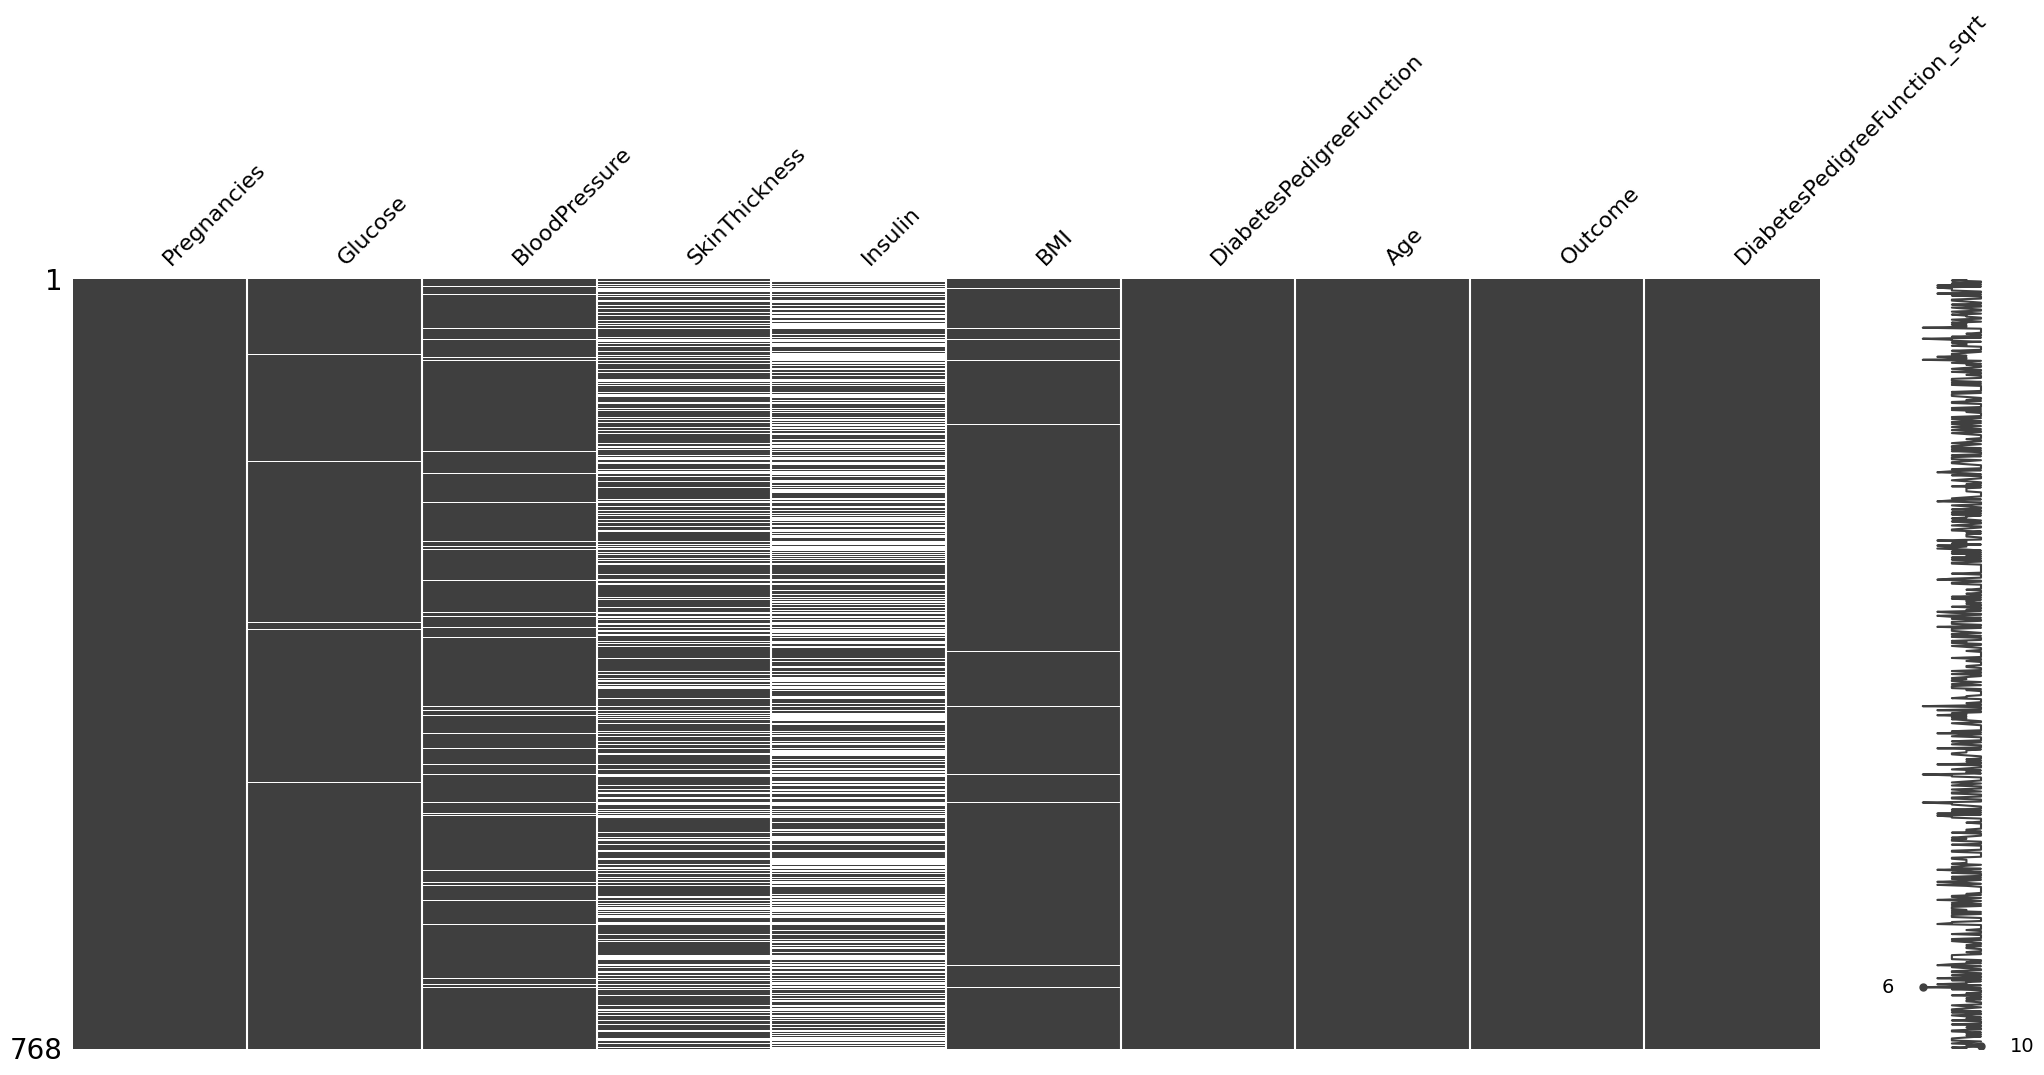

In [19]:
msno.matrix(df)
plt.show()

## 3.13 ELIMINAR COLUMNA CON 48% DE DATOS FALTANTES 

In [20]:
df = df.drop(columns=['Insulin'])  # Elimino Insulin porque tiene muchos valores faltantes

# 4 DIVISIÓN DATASET TRAIN-TEST 

In [21]:
# PASO 1: Preparar X e Y
X = df.drop('Outcome',axis=1)
Y = df['Outcome']

# PASO 2: Reemplazar -1 con NaN ANTES de dividir
# X = X.replace(-1, np.nan) ## Este paso es importante para que los -1 no afecten el entrenamiento del modelo 
# solo se aplica cuando se ha realizado codificación categorica previamente ya que asume que los nan son -1

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")
print(f"\n Valores nulos en train antes de imputar:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])
print(f"\n Valores nulos en test antes de imputar:")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

Tamaño del conjunto de entrenamiento: (614, 8)
Tamaño del conjunto de prueba: (154, 8)

 Valores nulos en train antes de imputar:
Glucose            5
BloodPressure     24
SkinThickness    176
BMI                7
dtype: int64

 Valores nulos en test antes de imputar:
BloodPressure    11
SkinThickness    51
BMI               4
dtype: int64


# 5 IMPUTACIÓN DE VALORES FALTANTES 

In [23]:
# Aplicar SimpleImputer SOLO en train (todas las variables son numéricas)
print("Imputando valores faltantes con la mediana del conjunto de entrenamiento...")

# Crear el imputador con estrategia 'median' (robusta a outliers)
imputer = SimpleImputer(strategy='median')

# Fit en train y transformar train
X_train_imputado = imputer.fit_transform(X_train)  # Aprende SOLO de train

# Convertir de vuelta a DataFrame
X_train_imputado = pd.DataFrame(
    X_train_imputado, 
    columns=X_train.columns, 
    index=X_train.index
)

print("\nImputación de entrenamiento completada!")
print(f"Valores nulos en train después de imputar: {X_train_imputado.isnull().sum().sum()}")

# Transformar test usando las medianas aprendidas de train
X_test_imputado = imputer.transform(X_test)  # Solo transform, NO fit

# Convertir de vuelta a DataFrame
X_test_imputado = pd.DataFrame(
    X_test_imputado, 
    columns=X_test.columns, 
    index=X_test.index
)

print(f"Valores nulos en test después de imputar: {X_test_imputado.isnull().sum().sum()}")

Imputando valores faltantes con la mediana del conjunto de entrenamiento...

Imputación de entrenamiento completada!
Valores nulos en train después de imputar: 0
Valores nulos en test después de imputar: 0


### ¿Cuándo usar MissForest?

- Cuando tienes variables categóricas Y numéricas mezcladas

- Cuando el porcentaje de valores faltantes es muy alto (>60%)

- Cuando las variables tienen relaciones complejas entre sí

# 6 VERIFICACIÓN DE OUTLIERS DESPUÉS DE IMPUTAR 

In [24]:
iso = IsolationForest(random_state=123)
df_num = X_train_imputado.copy()
df_num['outlier_flag'] = iso.fit_predict(X_train_imputado)

In [25]:
df_num['outlier_flag'].value_counts(normalize=True)*100

outlier_flag
 1    86.319218
-1    13.680782
Name: proportion, dtype: float64

# 7 COMPARACIÓN DE OUTLIERS ANTES Y DESPUÉS DE IMPUTAR 

In [26]:
# Función para detectar outliers con IQR por fila
def detectar_outliers_iqr_por_fila(df):
    """Marca cada fila que tiene al menos 1 outlier en cualquier variable"""
    outlier_mask = pd.Series(False, index=df.index)
    
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_bajo = Q1 - 1.5 * IQR
        limite_alto = Q3 + 1.5 * IQR
        
        # Marcar filas con outliers (ignora NaN)
        col_outliers = (df[col] < limite_bajo) | (df[col] > limite_alto)
        outlier_mask = outlier_mask | col_outliers
    
    return outlier_mask

print("Función detectar_outliers_iqr_por_fila() creada exitosamente ✅")

Función detectar_outliers_iqr_por_fila() creada exitosamente ✅


In [27]:
# 1. Outliers ANTES (IQR)
outliers_antes = detectar_outliers_iqr_por_fila(X_train)

# 2. Outliers DESPUÉS (IsolationForest)
iso = IsolationForest(random_state=123, contamination=0.1)
outliers_despues = (iso.fit_predict(X_train_imputado) == -1)

# 3. Comparación
comparacion = pd.DataFrame({
    'Antes_IQR': outliers_antes.astype(int),
    'Despues_ISO': outliers_despues.astype(int)
})

# 4. Tabla cruzada
print(pd.crosstab(comparacion['Antes_IQR'], comparacion['Despues_ISO'], 
                   rownames=['IQR'], colnames=['IsolationForest'], margins=True))

# 5. Concordancia
concordancia = (comparacion['Antes_IQR'] == comparacion['Despues_ISO']).mean() * 100
print(f"\n✅ Concordancia: {concordancia:.1f}%")

IsolationForest    0   1  All
IQR                          
0                532  25  557
1                 20  37   57
All              552  62  614

✅ Concordancia: 92.7%


CONCLUSIÓN: COMPARAR LOS OUTLIERS ANTES Y DESPUÉS DE IMPUTAR ES IMPORTANTE PORQUE ME DA UNA IDEA CLARA SI LA IMPUTACIÓN Y MANEJO DE LAS VARIABLES FUÉ CORRECTA O NO. EN ESTE CASO CON UN 92.7 % DE CONCORDANCIA PODEMOS DECIR QUE LA IMPUTACIÓN FUÉ CORRECTA Y NO DISTORCIONÓ LOS DATOS 

# 8 MÉTODOS DE SELECCIÓN DE CARACTERÍSTICAS 

## 8.1 MÉTODO 1: FEATURE IMPORTANCE DE RF

In [28]:
# Entrenamiento de RF
model = RandomForestClassifier(random_state=42,n_jobs=-1).fit(X_train_imputado,Y_train)

In [29]:
# Importancia de características
importances = model.feature_importances_/model.feature_importances_.sum()*100

# Convertir a DataFrame
df_rf_imp = pd.DataFrame({'feature': X_train_imputado.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)

# Calculamos la importancia acumulada
df_rf_imp['rf_importance_acum'] = df_rf_imp['rf_importance'].cumsum()

In [30]:
df_rf_imp

,feature,rf_importance,rf_importance_acum
1,Glucose,26.133399,26.133399
4,BMI,15.147208,41.280607
6,Age,13.152806,54.433413
5,DiabetesPedigreeFunction,11.200252,65.633665
7,DiabetesPedigreeFunction_sqrt,10.340225,75.973890
3,SkinThickness,8.524122,84.498012
2,BloodPressure,8.377590,92.875602
0,Pregnancies,7.124398,100.000000


## 8.2 MÉTODO 2: PERMUTATION/SHUFFLE IMPORTANCE

In [31]:
# Para esta técnica y la de shap se necesita conjunto de validación
X_train1, X_val, y_train1, y_val = train_test_split(X_train_imputado, Y_train, test_size=0.2, random_state=42)

# Ajustamos el modelo
model_xgb = XGBClassifier(objective='binary:logistic', random_state=42).fit(X_train1, y_train1)

In [32]:
# Realizamos 10 permutaciones por cada característica
perm = permutation_importance(model_xgb, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1, scoring='recall')

In [33]:
df_perm_imp = pd.DataFrame({'feature': X_train_imputado.columns, 'perm_imp': perm.importances_mean*100}).sort_values('perm_imp', ascending=False)
df_perm_imp

,feature,perm_imp
1,Glucose,20.476190
4,BMI,4.523810
6,Age,3.095238
7,DiabetesPedigreeFunction_sqrt,0.000000
0,Pregnancies,-0.238095
5,DiabetesPedigreeFunction,-0.714286
3,SkinThickness,-0.952381
2,BloodPressure,-2.619048


CONCLUSIÓN: HE DECIDIDO USAR EL SCORIG RECALL PORQUE CONSIDERO QUE EN CASOS MÉDICOS EL COSTO DE UN FALSO NEGATIVO ES MUY ALTO YA QUE SE TRATARÍA DE UN PACIENTE DIABÉTICO NO TRATADO.

## 8.3 MÉTODO 3: SHAP

In [34]:
# Ajustamos el modelo
model_lgbm = lgb.LGBMClassifier(random_state=42, n_jobs=-1).fit(X_train1, y_train1)

explainer = shap.Explainer(model_lgbm, X_val)   # usa el mismo X_val
shap_vals = explainer(X_val).values

[LightGBM] [Info] Number of positive: 171, number of negative: 320
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000356 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 672
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348269 -> initscore=-0.626657
[LightGBM] [Info] Start training from score -0.626657
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [35]:
imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap_imp = pd.DataFrame({"feature": X_val.columns, "shap_imp": imp_shap_pct}).sort_values('shap_imp', ascending=False)
df_shap_imp

,feature,shap_imp
1,Glucose,28.130853
6,Age,20.029302
4,BMI,15.387593
5,DiabetesPedigreeFunction,14.160117
3,SkinThickness,8.747241
2,BloodPressure,8.700406
0,Pregnancies,4.844489
7,DiabetesPedigreeFunction_sqrt,0.000000


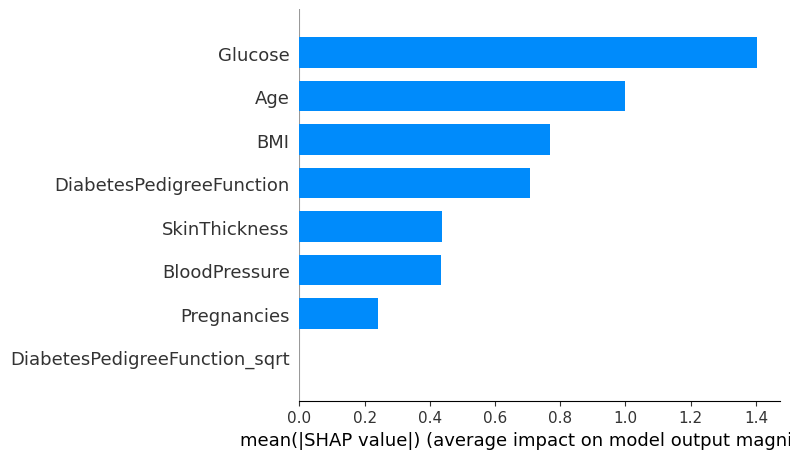

In [36]:
# SHAP Summary Bar Plot ---
shap.summary_plot(shap_vals, X_val, plot_type="bar")

## 8.4 UNIÓN DE LOS 3 MÉTODOS 

In [37]:
df_importances_sorted = (
    df_rf_imp
    .merge(df_perm_imp, on='feature', how='outer')
    .merge(df_shap_imp, on='feature', how='outer')
).sort_values('rf_importance', ascending=False)

df_importances_sorted

,feature,rf_importance,rf_importance_acum,perm_imp,shap_imp
5,Glucose,26.133399,26.133399,20.476190,28.130853
1,BMI,15.147208,41.280607,4.523810,15.387593
0,Age,13.152806,54.433413,3.095238,20.029302
3,DiabetesPedigreeFunction,11.200252,65.633665,-0.714286,14.160117
4,DiabetesPedigreeFunction_sqrt,10.340225,75.973890,0.000000,0.000000
7,SkinThickness,8.524122,84.498012,-0.952381,8.747241
2,BloodPressure,8.377590,92.875602,-2.619048,8.700406
6,Pregnancies,7.124398,100.000000,-0.238095,4.844489


## 8.5 ANÁLISIS DE VARIABLES A ELIMINAR 

#### CRITERIO UTILIZADO:

Estrategia Recomendada (Enfoque Conservador): Elimina una variable SOLO SI cumple AL MENOS 2 de estos 3 criterios:

-Random Forest < 5% de importancia

-Permutation Importance < 0 (negativa o cercana a 0)

-SHAP < 5% de importancia

In [38]:
# ANÁLISIS PARA DECISIÓN DE ELIMINACIÓN DE VARIABLES
print("="*80)
print("ANÁLISIS PARA SELECCIÓN DE VARIABLES A ELIMINAR")
print("="*80)

# Definir umbrales
umbral_bajo = 5.0  # Umbral de importancia baja (%)

# Identificar variables a eliminar según criterios
variables_eliminar = []

# Calcular el promedio de importancia entre los 3 métodos
df_importances_sorted['importancia_promedio'] = df_importances_sorted[['rf_importance', 'perm_imp', 'shap_imp']].mean(axis=1)

for idx, row in df_importances_sorted.iterrows():
    feature = row['feature']
    rf = row['rf_importance']
    perm = row['perm_imp']
    shap = row['shap_imp']
    promedio = row['importancia_promedio']
    
    # Contador de criterios cumplidos
    criterios_cumplidos = 0
    razones = []
    
    # Criterio 1: RF < 5%
    if rf < umbral_bajo:
        criterios_cumplidos += 1
        razones.append(f"RF={rf:.2f}%")
    
    # Criterio 2: Permutation < 0 (negativa)
    if perm < 0:
        criterios_cumplidos += 1
        razones.append(f"Perm={perm:.2f}% (NEGATIVA)")
    
    # Criterio 3: SHAP < 5%
    if shap < umbral_bajo:
        criterios_cumplidos += 1
        razones.append(f"SHAP={shap:.2f}%")
    
    # Si cumple 2+ criterios, marcar para eliminar
    if criterios_cumplidos >= 2:
        variables_eliminar.append({
            'feature': feature,
            'rf_importance': rf,
            'perm_imp': perm,
            'shap_imp': shap,
            'importancia_promedio': promedio,
            'criterios_cumplidos': criterios_cumplidos,
            'razones': ' | '.join(razones)
        })

# Mostrar resultados
if len(variables_eliminar) > 0:
    df_eliminar = pd.DataFrame(variables_eliminar)
    print(f"\nVARIABLES RECOMENDADAS PARA ELIMINAR ({len(variables_eliminar)}):")
    print("="*80)
    print(df_eliminar[['feature', 'rf_importance', 'perm_imp', 'shap_imp', 
                       'criterios_cumplidos', 'razones']].to_string(index=False))
    
    print("\n" + "="*80)
    print("LISTA DE VARIABLES A ELIMINAR:")
    print(df_eliminar['feature'].tolist())
    
    # Guardar lista para usar después
    features_to_drop = df_eliminar['feature'].tolist()
    
else:
    print("\n✅ NO HAY VARIABLES RECOMENDADAS PARA ELIMINAR")
    print("Todas las variables tienen importancia significativa en al menos 2 métodos")
    features_to_drop = []

print("\n" + "="*80)
print("RESUMEN:")
print(f"  • Variables originales: {len(df_importances_sorted)}")
print(f"  • Variables a eliminar: {len(features_to_drop)}")
print(f"  • Variables a mantener: {len(df_importances_sorted) - len(features_to_drop)}")

ANÁLISIS PARA SELECCIÓN DE VARIABLES A ELIMINAR

VARIABLES RECOMENDADAS PARA ELIMINAR (1):
    feature  rf_importance  perm_imp  shap_imp  criterios_cumplidos                             razones
Pregnancies       7.124398 -0.238095  4.844489                    2 Perm=-0.24% (NEGATIVA) | SHAP=4.84%

LISTA DE VARIABLES A ELIMINAR:
['Pregnancies']

RESUMEN:
  • Variables originales: 8
  • Variables a eliminar: 1
  • Variables a mantener: 7


## 8.6 FILTRADO DE VARIABLES SEGÚN CRITERIO ESTABLECIDO 

In [39]:
# Eliminar variables recomendadas
df_filt = df_importances_sorted[df_importances_sorted['feature'].isin(features_to_drop) == False]
df_filt

,feature,rf_importance,rf_importance_acum,perm_imp,shap_imp,importancia_promedio
5,Glucose,26.133399,26.133399,20.476190,28.130853,24.913481
1,BMI,15.147208,41.280607,4.523810,15.387593,11.686204
0,Age,13.152806,54.433413,3.095238,20.029302,12.092449
3,DiabetesPedigreeFunction,11.200252,65.633665,-0.714286,14.160117,8.215361
4,DiabetesPedigreeFunction_sqrt,10.340225,75.973890,0.000000,0.000000,3.446742
7,SkinThickness,8.524122,84.498012,-0.952381,8.747241,5.439661
2,BloodPressure,8.377590,92.875602,-2.619048,8.700406,4.819649


In [40]:
features = df_filt['feature']
features

5                          Glucose
1                              BMI
0                              Age
3         DiabetesPedigreeFunction
4    DiabetesPedigreeFunction_sqrt
7                    SkinThickness
2                    BloodPressure
Name: feature, dtype: object

## 8.7 APLICAMOS VIF A LAS VARIABLES FILTRADAS 

In [41]:
X_vif = add_constant(X_train_imputado[features])

vif = pd.Series([variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],index=X_vif.columns)
vif = vif.drop("const")
vif

Glucose                           1.172422
BMI                               1.652790
Age                               1.212190
DiabetesPedigreeFunction         22.638335
DiabetesPedigreeFunction_sqrt    22.493373
SkinThickness                     1.518006
BloodPressure                     1.219286
dtype: float64

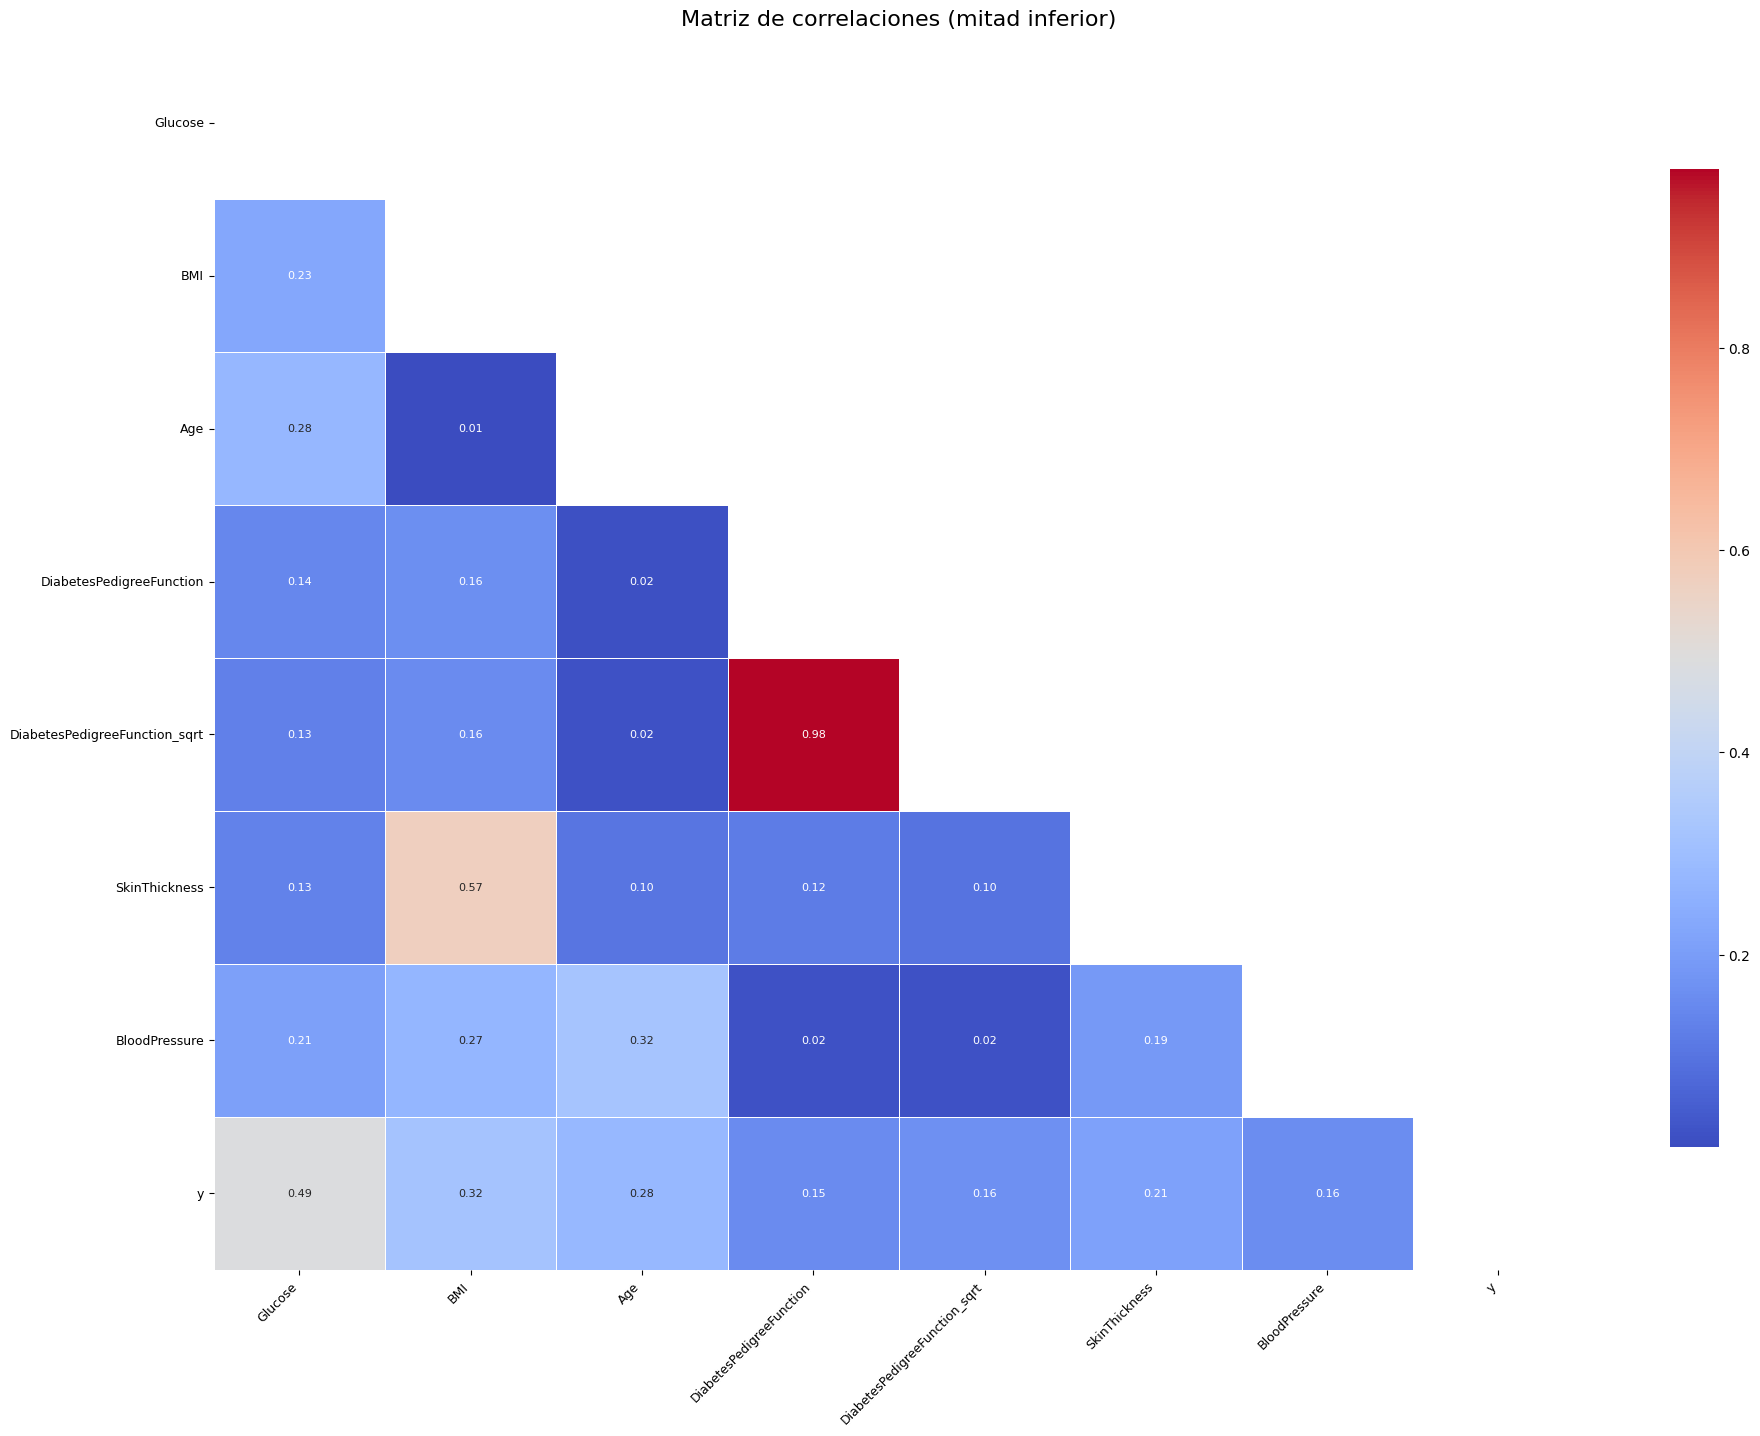

In [42]:
X_copy = X_train_imputado[features].copy()
X_copy['y'] = Y_train
corr = X_copy.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 15))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

CONCLUSIÓN: ES LÓGICO QUE ESXISTA MULTICOLINEALIDAD EN ESTAS DOS VARIABLES (DiabetesPedigreeFunction, DiabetesPedigreeFunction_sqrt). YA QUE UNA ES LA TRANSFORMACIÓN MATEMÁTICA DE LA OTRA, COMO ESTABA EXPERIMENTANDO SI ESTA TRANSFORMACIÓN FUNCIONABA MEJOR HE LLEGADO HASTA EL FINAL CON LAS DOS VARIABLES, PERO EN ESTE PUNTO ME HE DADO CUENTA EN BASE A LOS MÉTODOS APLICADOS PARA SELECCION DE VARIABLES QUE POR RANGO DE IMPORTANCIA LO MAS CORRECTO ES TRABAJAR CON LA VARIABLE ORIGINAL. NO SIEMPRE LAS TRANSFORMACIONES SON SINÓNIMOS DE MEJORAS!!! TRABAJAR CON LOS DATOS ORIGINALES ME BENEFICIARÁ PARA UNA MEJOR INTERPRETABILIDAD.

SIN EMBARGO VOY APLICAR CROSS VALIDATION EN LAS VARIABLES (SkinThickness y BMI) YA QUE EN EL GRÁFICO TAMBIÉN SE APRECIA UNA MULTICOLINEALIDAD MAS LIGERA PERO QUE PUEDE SER INTERESANTE ESTUDIAR....

## 8.9 ELIMINAMOS LA VARIABLE (DiabetesPedigreeFunction_sqrt)

In [43]:
# Eliminar y Actualizar features eliminando DiabetesPedigreeFunction_sqrt
features = [f for f in features if f != 'DiabetesPedigreeFunction_sqrt']
print(f"Features actualizadas: {features}")


Features actualizadas: ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'SkinThickness', 'BloodPressure']


## 8.10 APLICAMOS CROSS VALIDATION (SkinThickness y BMI)

In [44]:
# Versión 1: Realizar cross_validation con todas las características que son candidatas
cv_resultsF1 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), X_train_imputado[features], Y_train, cv=3, scoring='recall')
cv_resultsF1.mean()

np.float64(0.5962441314553991)

In [45]:
# Versión 2: Realizar cross_validation con  las características que son candidatas sin las correlacionadas
cv_resultsF1_2 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), X_train_imputado[features].drop(['SkinThickness'],axis=1), Y_train, cv=3, scoring='recall', n_jobs=-1)
cv_resultsF1_2.mean()

np.float64(0.5680751173708921)

In [46]:
# Versión 2: Realizar cross_validation con  las características que son candidatas sin las correlacionadas
cv_resultsF1_2 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), X_train_imputado[features].drop(['BMI'],axis=1), Y_train, cv=3, scoring='recall', n_jobs=-1)
cv_resultsF1_2.mean()

np.float64(0.5446009389671361)

CONCLUSIÓN:LA MEJOR VERSIÓN ES LA QUE INCLUYE TODAS LAS VARIABLES CANDIDATAS!! YA QUE MAXIMIZA LAMÉTRICA SELCCIONADA!

# 9 MODELADO

## 9.1 VARIABLES FINALES SELECCIONADAS PARA EL MODELO

In [47]:
X_train = X_train_imputado[features]
X_test = X_test_imputado[features]

In [48]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Glucose,614.0,121.815961,30.104012,44.000,100.0000,118.0000,139.00000,199.00
BMI,614.0,32.348208,6.935618,18.200,27.3250,32.0000,36.37500,67.10
Age,614.0,32.907166,11.503437,21.000,24.0000,29.0000,40.00000,81.00
DiabetesPedigreeFunction,614.0,0.469168,0.336847,0.078,0.2415,0.3725,0.61375,2.42
SkinThickness,614.0,28.568404,8.410029,8.000,24.0000,28.5000,32.00000,63.00
BloodPressure,614.0,72.229642,12.099278,24.000,64.0000,72.0000,80.00000,122.00


## 9.2 APLICACIÓN DE DECISION TREE SIMPLE Y COMPLEJO

In [49]:
simple_tree = DecisionTreeClassifier(max_depth=3, max_features=X_train.shape[1]//2, min_samples_leaf=20, random_state=42)
simple_tree.fit(X_train, Y_train)

complex_tree = DecisionTreeClassifier(max_depth=100, min_samples_leaf=1, random_state=42)
complex_tree.fit(X_train, Y_train)

# Evaluar el modelo complejo en entrenamiento y prueba
train_pred_complex = complex_tree.predict(X_train)
test_pred_complex = complex_tree.predict(X_test)

# Evaluar el modelo simple en entrenamiento y prueba
train_pred_simple = simple_tree.predict(X_train)
test_pred_simple = simple_tree.predict(X_test)

In [50]:
def get_metrics(y_train, y_test, y_pred_train, y_pred_test):
    # Calcular métricas para el conjunto de entrenamiento
    train_accuracy = accuracy_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train)
    train_auc = roc_auc_score(y_train, y_pred_train)
    train_precision = precision_score(y_train, y_pred_train)
    train_recall = recall_score(y_train, y_pred_train)
    train_specificity = specificity_score(y_train, y_pred_train)

    # Calcular métricas para el conjunto de prueba
    test_accuracy = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_auc = roc_auc_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_specificity = specificity_score(y_test, y_pred_test)

    # Calcular la diferencia entre métricas de entrenamiento y prueba
    diff_accuracy = train_accuracy - test_accuracy
    diff_f1 = train_f1 - test_f1
    diff_auc = train_auc - test_auc
    diff_precision = train_precision - test_precision
    diff_recall = train_recall - test_recall
    diff_specificity = train_specificity - test_specificity

    # Crear un DataFrame con los resultados
    metrics_df = pd.DataFrame([[train_accuracy, train_f1, train_auc, train_precision, train_recall, train_specificity],[test_accuracy, test_f1, test_auc, test_precision, test_recall, test_specificity],[diff_accuracy, diff_f1, diff_auc, diff_precision, diff_recall, diff_specificity]],
                              columns = ['Accuracy', 'F1', 'AUC', 'Precision', 'Recall', 'Specificity'],
                              index = ['Train','Test', 'Diferencia'])

    return metrics_df

In [51]:
get_metrics(Y_train, Y_test, train_pred_complex, test_pred_complex)

,Accuracy,F1,AUC,Precision,Recall,Specificity
Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000
Test,0.772727,0.695652,0.762626,0.666667,0.727273,0.79798
Diferencia,0.227273,0.304348,0.237374,0.333333,0.272727,0.20202


In [52]:
get_metrics(Y_train, Y_test, train_pred_simple, test_pred_simple)

,Accuracy,F1,AUC,Precision,Recall,Specificity
Train,0.776873,0.649616,0.734531,0.713483,0.596244,0.872818
Test,0.772727,0.660194,0.738384,0.708333,0.618182,0.858586
Diferencia,0.004146,-0.010578,-0.003853,0.005150,-0.021938,0.014232


CONCLUSIÓN: A PESAR DE TENER MEJORES RESULTADOS CON EL MODELO COMPLEJO NOS DAMOS CUENTA QUE FALLA MUCHO MÁS AL PREDECIR CON RESPECTO AL MODELO SIMPLE, LO QUE NOS INDICA QUE PUEDE ESTAR MEMORIZANDO! EN MACHINE LEARNING NOS INTERESA MAS QUE EL MODELO PREDIGA MEJOR LOS DATOS QUE OBTENER VALORES PERFECTOS EN ENTRENAMIENTO. EL MODELO SIMPLE GENERALIZA MEJOR TANTO EN TRAIN COMO EN TEST

## 9.3 MATRIZ DE CONFUSIÓN MÉTODO SELECCIONADO TREE SIMPLE

In [53]:
# Matriz de confusión
cm = confusion_matrix(Y_test, test_pred_simple)
cm

array([[85, 14],
       [21, 34]])

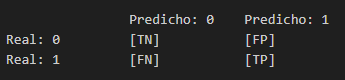

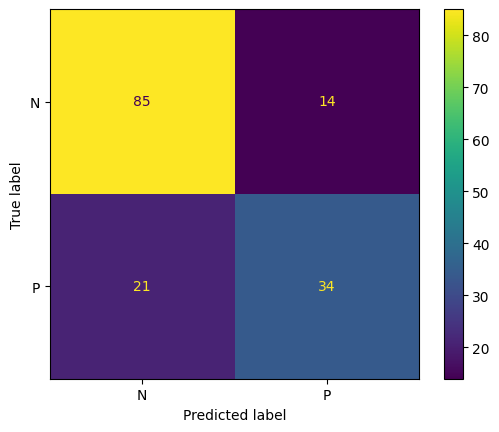

In [54]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['N', 'P'])
disp.plot()

In [55]:
text_representation = export_text(simple_tree, feature_names=list(X_train.columns), show_weights=True)
print(text_representation)

|--- Glucose <= 127.50
|   |--- BMI <= 26.45
|   |   |--- DiabetesPedigreeFunction <= 0.63
|   |   |   |--- weights: [83.00, 0.00] class: 0
|   |   |--- DiabetesPedigreeFunction >  0.63
|   |   |   |--- weights: [19.00, 1.00] class: 0
|   |--- BMI >  26.45
|   |   |--- Age <= 28.50
|   |   |   |--- weights: [135.00, 16.00] class: 0
|   |   |--- Age >  28.50
|   |   |   |--- weights: [77.00, 59.00] class: 0
|--- Glucose >  127.50
|   |--- Glucose <= 159.50
|   |   |--- BMI <= 29.95
|   |   |   |--- weights: [36.00, 10.00] class: 0
|   |   |--- BMI >  29.95
|   |   |   |--- weights: [38.00, 59.00] class: 1
|   |--- Glucose >  159.50
|   |   |--- Glucose <= 167.50
|   |   |   |--- weights: [6.00, 14.00] class: 1
|   |   |--- Glucose >  167.50
|   |   |   |--- weights: [7.00, 54.00] class: 1



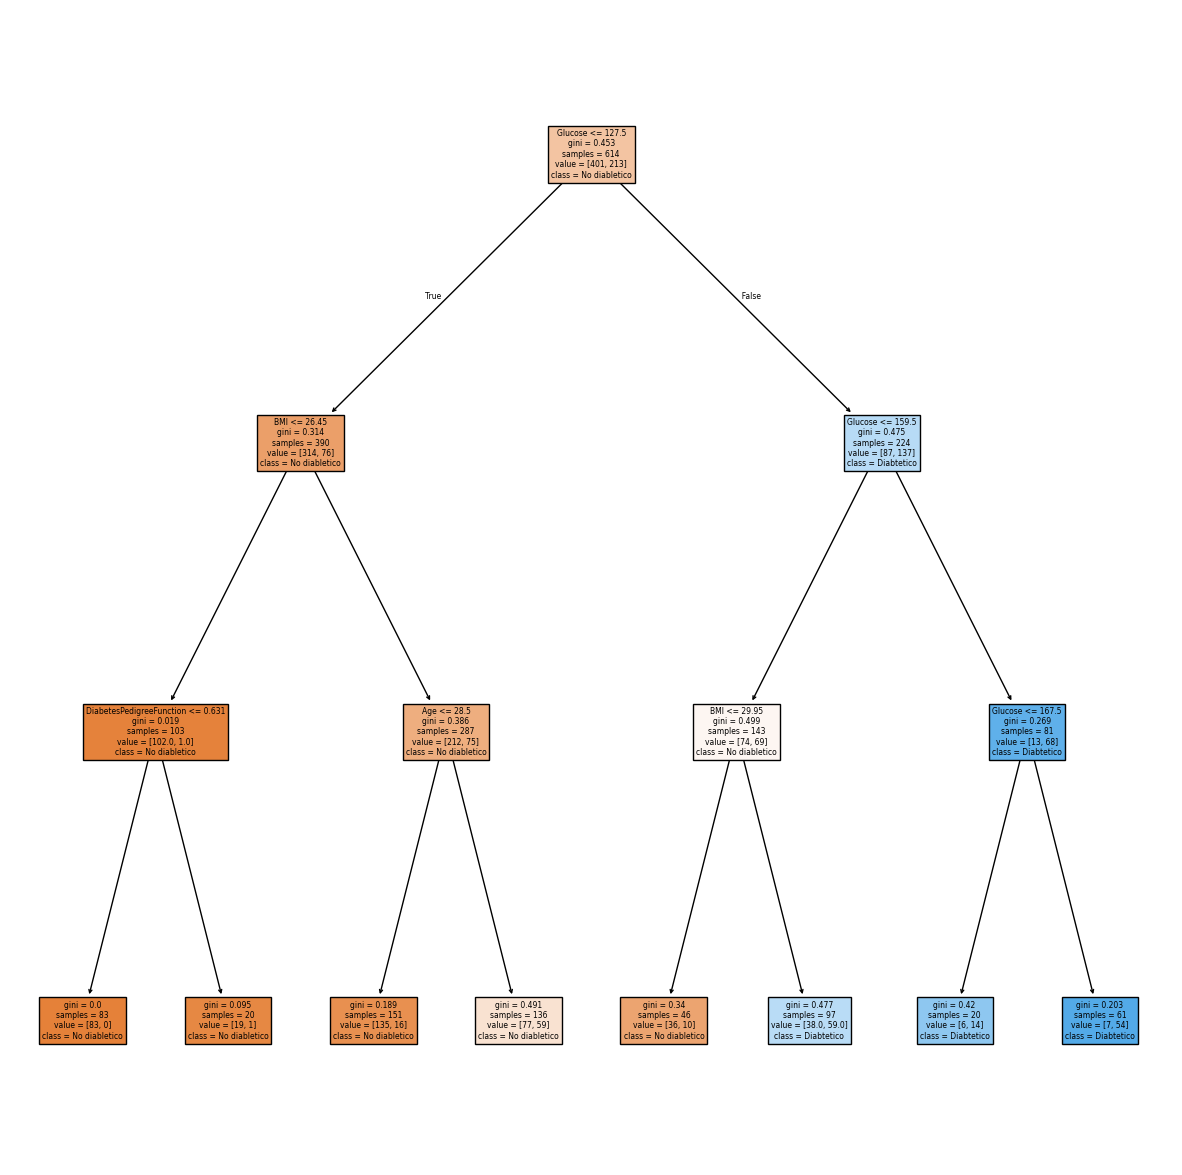

In [56]:
# Gráfico del Árbol de Decisión
fig = plt.figure(figsize=(15,15))
plot_tree(simple_tree, feature_names = list(X_train_imputado[features].columns), class_names = ["No diabletico", "Diabtetico"], filled = True)
plt.show()

## 9.5 CONCLUSIÓN DE PREDICCIONES DEL MÉTODO SELECCIONADO

#### La Glucosa es el Factor Determinante

##### 1- Glucosa ≤ 127.5 mg/dL → NO DIABÉTICO 

Todos los pacientes con glucosa baja son clasificados como NO diabéticos (clase 0), sin importar su BMI, edad o historial familiar. Este grupo representa la mayoría de casos negativos (314 pacientes no diabéticos vs 76 diabéticos).

##### 2- Glucosa > 127.5 mg/dL → Riesgo según nivel:

- Glucosa Moderada (127.5-159.5 mg/dL):

BMI ≤ 29.95: Clasificado como NO diabético (36 vs 10)

BMI > 29.95: Clasificado como DIABÉTICO (38 vs 59)

Conclusión: La obesidad (BMI ≥30) es el factor crítico en este rango de glucosa

- Glucosa Alta (> 159.5 mg/dL) → SIEMPRE DIABÉTICO

El modelo predice diabetes independientemente de otras variables

#### Conclusión General 
Glucosa < 127.5 = Negativo | Glucosa 127.5-159.5 + Obesidad = Riesgo Alto | Glucosa > 159.5 = Diabetes Confirmada 

    El modelo identifica correctamente que la glucosa elevada es el indicador más fuerte de diabetes, y que la obesidad amplifica el riesgo cuando la glucosa ya está alterada.



# 10 COMPROBACIÓN CON TODOS CRITERIOS DE LA FUNCIÓN DE PUREZA DE LOS NODOS 

In [57]:
# Modelo con Gini
simple_tree_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, max_features=X_train.shape[1]//2, min_samples_leaf=20, random_state=42)
simple_tree_gini.fit(X_train, Y_train)
pred_gini = simple_tree_gini.predict(X_test)

# Modelo con Entropy
simple_tree_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, max_features=X_train.shape[1]//2, min_samples_leaf=20, random_state=42)
simple_tree_entropy.fit(X_train, Y_train)
pred_entropy = simple_tree_entropy.predict(X_test)

# Modelo con Log Loss
simple_tree_logloss = DecisionTreeClassifier(criterion='log_loss', max_depth=3, max_features=X_train.shape[1]//2, min_samples_leaf=20, random_state=42)
simple_tree_logloss.fit(X_train, Y_train)
pred_logloss = simple_tree_logloss.predict(X_test)

# Comparar métricas
print("="*80)
print("CRITERIO: GINI")
print("="*80)
print(get_metrics(Y_train, Y_test, simple_tree_gini.predict(X_train), pred_gini))

print("\n" + "="*80)
print("CRITERIO: ENTROPY")
print("="*80)
print(get_metrics(Y_train, Y_test, simple_tree_entropy.predict(X_train), pred_entropy))

print("\n" + "="*80)
print("CRITERIO: LOG LOSS")
print("="*80)
print(get_metrics(Y_train, Y_test, simple_tree_logloss.predict(X_train), pred_logloss))

CRITERIO: GINI
            Accuracy        F1       AUC  Precision    Recall  Specificity
Train       0.776873  0.649616  0.734531   0.713483  0.596244     0.872818
Test        0.772727  0.660194  0.738384   0.708333  0.618182     0.858586
Diferencia  0.004146 -0.010578 -0.003853   0.005150 -0.021938     0.014232

CRITERIO: ENTROPY
            Accuracy        F1       AUC  Precision    Recall  Specificity
Train       0.776873  0.644156  0.731229   0.720930  0.582160     0.880299
Test        0.772727  0.660194  0.738384   0.708333  0.618182     0.858586
Diferencia  0.004146 -0.016038 -0.007154   0.012597 -0.036022     0.021713

CRITERIO: LOG LOSS
            Accuracy        F1       AUC  Precision    Recall  Specificity
Train       0.776873  0.644156  0.731229   0.720930  0.582160     0.880299
Test        0.772727  0.660194  0.738384   0.708333  0.618182     0.858586
Diferencia  0.004146 -0.016038 -0.007154   0.012597 -0.036022     0.021713


[]

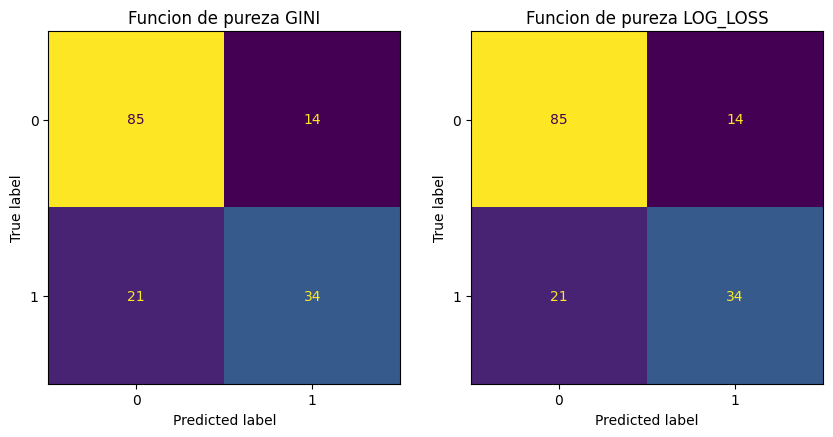

In [58]:
# Matriz de Confusión
## GINI
cm_gini = confusion_matrix(Y_test, pred_gini)
## LOG-LOSS
cm_log = confusion_matrix(Y_test, pred_logloss)

#Gráfico

fig, axis=plt.subplots(1,2, figsize=(10,5))
ConfusionMatrixDisplay(confusion_matrix=cm_gini).plot(ax=axis[0],cmap='viridis',colorbar=False)
axis[0].set_title("Funcion de pureza GINI")
ConfusionMatrixDisplay(confusion_matrix=cm_log).plot(ax=axis[1],cmap='viridis', colorbar=False)
axis[1].set_title("Funcion de pureza LOG_LOSS")
plt.plot()

CONCLUSIÓN: EN ÁRBOLES SIMPLE CON POCA PROFUNDIDAD LOS TRES CRITERIOS PUEDEN LLEGAR  A LAS MISMAS DIVISIONES. POR ESO EL RESULTADO EN ESTE CASO ES IGUAL YA QUE MAX_DEPTH = 3

# 11 OPTIMIZACIÓN

In [59]:
from sklearn.model_selection import GridSearchCV

# Definir el espacio de hiperparámetros a explorar
param_grid = {
    'max_depth': [2, 3, 4, 5],
    # EXPLICACIÓN: Actualmente usas 3. Probar 2-5 para ver si más/menos 
    # profundidad mejora. Valores bajos previenen overfitting.
    
    'min_samples_leaf': [15, 20, 25],
    # EXPLICACIÓN: Actualmente usas 20. Probar 15-25 para encontrar el 
    # balance óptimo. Valores altos = más generalización, menos overfitting.
    
    'min_samples_split': [20, 30, 40],
    # EXPLICACIÓN: NO lo usabas antes. Define mínimo de muestras para dividir 
    # un nodo. Ayuda a controlar la complejidad del árbol.
    
    'max_features': [2, 3, 4],
    # EXPLICACIÓN: Actualmente usas X_train.shape[1]//2 = 3. Probar 2-4 
    # para encontrar el número óptimo de features por división.
    
    'min_impurity_decrease': [0.0, 0.001, 0.005],
    # EXPLICACIÓN: NUEVO parámetro. Umbral mínimo de mejora de pureza para 
    # dividir. 0.0 = sin restricción. Valores > 0 evitan divisiones poco útiles.
    
    'ccp_alpha': [0.0, 0.001, 0.005, 0.01]
    # EXPLICACIÓN: NUEVO parámetro. Cost Complexity Pruning. 0.0 = sin poda.
    # Valores > 0 podan el árbol para reducir overfitting. Muy efectivo.
}

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(criterion='log_loss', random_state=42),
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation (más robusto que 3)
    scoring='recall',  # Tu métrica prioritaria (casos médicos)
    n_jobs=-1,  # Usar todos los cores disponibles
    verbose=2,  # Mostrar progreso
    return_train_score=True  # Para detectar overfitting
)

# Calcular y mostrar el total de combinaciones
total_combinaciones = (len(param_grid['max_depth']) * 
                       len(param_grid['min_samples_leaf']) * 
                       len(param_grid['min_samples_split']) * 
                       len(param_grid['max_features']) * 
                       len(param_grid['min_impurity_decrease']) * 
                       len(param_grid['ccp_alpha']))

# Entrenar el modelo con búsqueda exhaustiva
print("="*80)
print("INICIANDO GRID SEARCH CV")
print("="*80)
print(f"Total de combinaciones a probar: {total_combinaciones}")
print(f"Con 5-fold CV: {total_combinaciones * 5} entrenamientos")
print("="*80)
grid_search.fit(X_train, Y_train)

# Mostrar los mejores parámetros encontrados
print("\n" + "="*80)
print("MEJORES HIPERPARÁMETROS ENCONTRADOS")
print("="*80)
for param, value in grid_search.best_params_.items():
    print(f"  • {param}: {value}")

# Mejor score de validación cruzada
print("\n" + "="*80)
print(f"Mejor Recall en Validación Cruzada: {grid_search.best_score_:.4f}")
print("="*80)

# Obtener el mejor modelo
best_tree = grid_search.best_estimator_

# Evaluar con tu función existente
pred_best = best_tree.predict(X_test)
print("\n" + "="*80)
print("MÉTRICAS DEL MODELO OPTIMIZADO")
print("="*80)
print(get_metrics(Y_train, Y_test, best_tree.predict(X_train), pred_best))

# Comparar con tu modelo original
print("\n" + "="*80)
print("COMPARACIÓN: MODELO ORIGINAL VS OPTIMIZADO")
print("="*80)
print(f"Recall Test Original: {recall_score(Y_test, pred_logloss):.4f}")
print(f"Recall Test Optimizado: {recall_score(Y_test, pred_best):.4f}")
print(f"Mejora: {(recall_score(Y_test, pred_best) - recall_score(Y_test, pred_logloss)):.4f}")

INICIANDO GRID SEARCH CV
Total de combinaciones a probar: 1296
Con 5-fold CV: 6480 entrenamientos
Fitting 5 folds for each of 1296 candidates, totalling 6480 fits



MEJORES HIPERPARÁMETROS ENCONTRADOS
  • ccp_alpha: 0.01
  • max_depth: 4
  • max_features: 4
  • min_impurity_decrease: 0.0
  • min_samples_leaf: 25
  • min_samples_split: 20

Mejor Recall en Validación Cruzada: 0.7788

MÉTRICAS DEL MODELO OPTIMIZADO
            Accuracy        F1       AUC  Precision    Recall  Specificity
Train       0.785016  0.742188  0.810099   0.635452  0.892019     0.728180
Test        0.707792  0.666667  0.732323   0.562500  0.818182     0.646465
Diferencia  0.077224  0.075521  0.077776   0.072952  0.073837     0.081715

COMPARACIÓN: MODELO ORIGINAL VS OPTIMIZADO
Recall Test Original: 0.6182
Recall Test Optimizado: 0.8182
Mejora: 0.2000


# 12 SELECCIÓN DEL MEJOR MODELO Y EXPORTACIÓN DEL MODELO FINAL 

In [62]:
joblib.dump(best_tree, 'diabete_prediction_model.pkl')
print("✅ Modelo guardado exitosamente como 'diabete_prediction_model.pkl'")

✅ Modelo guardado exitosamente como 'diabete_prediction_model.pkl'


In [63]:
# Cargamos el modelo
modelo_final = joblib.load('diabete_prediction_model.pkl')